In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Ensure the Datasets and validation_plots folders exist
os.makedirs('/content/drive/MyDrive/Datasets/validation_plots', exist_ok=True)

Mounted at /content/drive


In [ ]:
# %% [markdown]
# # Synthetic Microlensing Dataset Generation
# **Author**: Generated for Roc Rubió Cardona's "Gravitational Microlensing" research (TdR)
#
# Generates 100,000 ideal microlensing events:
# - 95,000 single lens events (Paczyński amplification)
# - 5,000 binary lens events (Jacobian inverse ray-shooting)
# - 400 time points per event, NO noise, NO photometric errors
# - All parameters sampled from distributions documented in TdR.pdf

In [ ]:
# Cell 1: Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import warnings
import time as timer
import sys

# Force UTF-8 output for Windows
if sys.stdout.encoding.lower() != 'utf-8':
    sys.stdout.reconfigure(encoding='utf-8')

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
# SEED = 41 # SEDD2
rng = np.random.default_rng(SEED)

# Matplotlib publication-quality settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.facecolor': 'white',
})

# --- Physical Constants (maximum precision, SI units) ---
G = np.float64(6.67430e-11)         # Gravitational constant [m^3 kg^-1 s^-2]
c = np.float64(2.99792458e8)        # Speed of light [m/s]
M_SUN = np.float64(1.98892e30)      # Solar mass [kg]
M_JUP = np.float64(1.89813e27)      # Jupiter mass [kg]
PC_TO_M = np.float64(3.0856775814913673e16)  # 1 parsec in meters
AU_TO_M = np.float64(1.495978707e11)         # 1 AU in meters
KM_TO_M = np.float64(1.0e3)         # 1 km in meters

# --- Dataset Configuration ---
N_SINGLE = 95_000    # Number of single-lens events
N_BINARY = 5_000     # Number of binary-lens events
N_TOTAL = N_SINGLE + N_BINARY
N_TIME = 400         # Time points per event

print(f"Configuration: {N_TOTAL:,} total events ({N_SINGLE:,} single + {N_BINARY:,} binary)")
print(f"Time points per event: {N_TIME}")
print(f"Random seed: {SEED}")

Configuration: 100,000 total events (95,000 single + 5,000 binary)
Time points per event: 400
Random seed: 42


## Parameter Distributions
Each distribution below is derived from figures and text in TdR.pdf.
All values are sampled with np.float64 precision.


In [ ]:
# Cell 2: Lens Mass M★ [Solar masses] — Bimodal Gaussian Mixture (TdR Image 2, p.21)
# The PDF histogram shows a bimodal distribution:
#   - Secondary peak near ~0.10 M☉ (low-mass lenses, likely M-dwarfs)
#   - Primary peak near ~0.45 M☉ (median marked in the plot)
#   - Long tail extending to ~1.2 M☉
# We model this as a 2-component Gaussian mixture in linear space.

def sample_lens_mass(n, rng):
    """Sample lens masses from bimodal Gaussian mixture.
    Component 1: Low-mass peak ~0.10 M☉ (M-dwarfs, ~25% weight)
    Component 2: Main peak ~0.45 M☉ (K/G-dwarfs, ~75% weight)
    Ref: TdR Image 2, p.21 — NASA Exoplanet Archive [11]
    """
    w1, mu1, sig1 = 0.25, 0.10, 0.06   # Low-mass component
    w2, mu2, sig2 = 0.75, 0.45, 0.22   # Main component

    # Determine which component each sample belongs to
    component = rng.choice([0, 1], size=n, p=[w1, w2])
    masses = np.empty(n, dtype=np.float64)

    mask1 = component == 0
    mask2 = component == 1
    masses[mask1] = rng.normal(mu1, sig1, size=mask1.sum())
    masses[mask2] = rng.normal(mu2, sig2, size=mask2.sum())

    # Clip to physical range [0.01, 1.2] M☉
    masses = np.clip(masses, 0.01, 1.2)
    return masses.astype(np.float64)

M_star_solar = sample_lens_mass(N_TOTAL, rng)
M_star_kg = M_star_solar * M_SUN
print(f"Lens Mass: min={M_star_solar.min():.4f}, median={np.median(M_star_solar):.4f}, max={M_star_solar.max():.4f} M☉")

Lens Mass: min=0.0100, median=0.3562, max=1.2000 M☉


In [ ]:
# Cell 3: Distance to Lens D_l [pc] — Bulge-peaked mixture (TdR Image 5, p.24)
# The PDF shows a strong peak at ~6,500–7,000 pc (Galactic bulge) with a
# secondary mild presence at 500–3,000 pc (disk lenses).
# Paczyński (1991) [10] confirms the bulge regime peak at 6–7 kpc.
# Median from data: 6,095 pc.

def sample_distance_to_lens(n, rng):
    """Sample D_l from Gaussian mixture: disk + bulge components.
    Component 1: Galactic disk lenses (~20%), broad, 500-3000 pc
    Component 2: Galactic bulge lenses (~80%), peaked at ~6800 pc
    Ref: TdR Image 5, p.24 — Paczyński (1991) [10]
    """
    w_disk, mu_disk, sig_disk = 0.20, 1500.0, 800.0
    w_bulge, mu_bulge, sig_bulge = 0.80, 6800.0, 750.0

    component = rng.choice([0, 1], size=n, p=[w_disk, w_bulge])
    distances = np.empty(n, dtype=np.float64)

    mask_disk = component == 0
    mask_bulge = component == 1
    distances[mask_disk] = rng.normal(mu_disk, sig_disk, size=mask_disk.sum())
    distances[mask_bulge] = rng.normal(mu_bulge, sig_bulge, size=mask_bulge.sum())

    # Clip to physical range [300, 8500] pc
    distances = np.clip(distances, 300.0, 8500.0)
    return distances.astype(np.float64)

D_l_pc = sample_distance_to_lens(N_TOTAL, rng)
D_l_m = D_l_pc * PC_TO_M
print(f"D_l: min={D_l_pc.min():.0f}, median={np.median(D_l_pc):.0f}, max={D_l_pc.max():.0f} pc")

D_l: min=300, median=6562, max=8500 pc


In [ ]:
# Cell 4: Lens-Source Distance D_ls [pc] — Structured uniform (TdR Image 4, p.23)
# The PDF describes the distribution as "irregular" and "more or less uniform"
# with a median of ~2,915 pc. The histogram shows mild peaks near 500 and 5000 pc.
# We use a weakly structured distribution: uniform base with mild Gaussian bumps.

def sample_lens_source_distance(n, rng):
    """Sample D_ls with structured uniform + mild peaks.
    Base: Uniform [100, 8000] pc (~70%)
    Peak 1: Gaussian at ~1000 pc, σ=500 (~15%)
    Peak 2: Gaussian at ~5000 pc, σ=800 (~15%)
    Ref: TdR Image 4, p.23 — NASA Exoplanet Archive [11]
    """
    w_unif = 0.70
    w_peak1, mu1, sig1 = 0.15, 1000.0, 500.0
    w_peak2, mu2, sig2 = 0.15, 5000.0, 800.0

    component = rng.choice([0, 1, 2], size=n, p=[w_unif, w_peak1, w_peak2])
    distances = np.empty(n, dtype=np.float64)

    m0 = component == 0
    m1 = component == 1
    m2 = component == 2
    distances[m0] = rng.uniform(100.0, 8000.0, size=m0.sum())
    distances[m1] = rng.normal(mu1, sig1, size=m1.sum())
    distances[m2] = rng.normal(mu2, sig2, size=m2.sum())

    distances = np.clip(distances, 100.0, 8000.0)
    return distances.astype(np.float64)

D_ls_pc = sample_lens_source_distance(N_TOTAL, rng)
D_ls_m = D_ls_pc * PC_TO_M
D_s_pc = D_l_pc + D_ls_pc   # Source distance = lens + lens-source
D_s_m = D_s_pc * PC_TO_M
print(f"D_ls: min={D_ls_pc.min():.0f}, median={np.median(D_ls_pc):.0f}, max={D_ls_pc.max():.0f} pc")

D_ls: min=100, median=3915, max=8000 pc


In [ ]:
# Cell 5: Lens Velocity v⊥ [km/s] — Maxwell-Boltzmann (TdR p.25, Ref [1])
# "Maxwell-Boltzmann distribution with a center of 200km/s" — Rahvar (2015)
# For Maxwell-Boltzmann: mode = σ√2, so σ = 200/√2 ≈ 141.42 km/s

def sample_lens_velocity(n, rng):
    """Sample transversal velocity from Maxwell-Boltzmann with mode=200 km/s.
    Ref: TdR p.25 — Rahvar (2015) [1]
    """
    mode_kms = np.float64(200.0)
    sigma = mode_kms / np.sqrt(np.float64(2.0))  # σ ≈ 141.42 km/s
    # Maxwell distribution: scipy uses scale parameter = σ
    velocities = stats.maxwell.rvs(scale=sigma, size=n, random_state=rng.integers(2**31))
    return velocities.astype(np.float64)

v_perp_kms = sample_lens_velocity(N_TOTAL, rng)
v_perp_ms = v_perp_kms * KM_TO_M
print(f"v⊥: min={v_perp_kms.min():.1f}, median={np.median(v_perp_kms):.1f}, max={v_perp_kms.max():.1f} km/s")

v⊥: min=2.4, median=217.7, max=731.4 km/s


In [ ]:
# Cell 6: Impact Parameter u₀ — Telescope-bias observed distribution (TdR Image 7, p.26)
# The observed OGLE-IV distribution (grey filled area in Image 7) shows a
# strong concentration near u₀=0 that decays roughly exponentially toward u₀=1.
# We model this as an exponential distribution truncated to [0, 1].
# From the figure, the decay rate λ ≈ 3 provides a good fit to the observed bias.

def sample_impact_parameter(n, rng):
    """Sample u₀ from truncated exponential (telescope bias).
    Observed distribution from OGLE-IV data [9] peaks strongly near 0
    and decays toward 1.
    Ref: TdR Image 7, p.26 — OGLE-IV [9]
    """
    lam = np.float64(3.0)  # Decay rate
    # Inverse CDF method for truncated exponential on [0, 1]
    u_max = 1.0 - np.exp(-lam * 1.0)
    u_uniform = rng.uniform(0.0, u_max, size=n)
    u0 = -np.log(1.0 - u_uniform) / lam
    # Ensure physical range and avoid exactly 0
    u0 = np.clip(u0, 1e-6, 1.0)
    return u0.astype(np.float64)

u0_all = sample_impact_parameter(N_TOTAL, rng)
print(f"u₀: min={u0_all.min():.6f}, median={np.median(u0_all):.4f}, max={u0_all.max():.4f}")

u₀: min=0.000002, median=0.2145, max=1.0000


In [ ]:
# Cell 7: Mass Ratio q — Log-normal (binary only) (TdR Image 3, p.22)
# The mass ratio q = M_p / (M★ + M_p) shows a bell-shaped distribution in
# log-space with peak (median) at ~1.43×10⁻³. Range spans ~10⁻⁶ to ~1.
# We model as log-normal: log₁₀(q) ~ Normal(μ=-2.845, σ=1.0)

def sample_mass_ratio(n, rng):
    """Sample mass ratio q from log-normal distribution.
    Ref: TdR Image 3, p.22 — NASA Exoplanet Archive [11]
    Peak at ~1.43e-3, spanning 1e-6 to 1 in log-space.
    """
    mu_log10 = np.float64(np.log10(1.43e-3))  # ≈ -2.845
    sigma_log10 = np.float64(1.0)
    log10_q = rng.normal(mu_log10, sigma_log10, size=n)
    q = np.power(np.float64(10.0), log10_q)
    q = np.clip(q, 1e-6, 0.999)
    return q.astype(np.float64)

q_binary = sample_mass_ratio(N_BINARY, rng)
print(f"q (binary): min={q_binary.min():.2e}, median={np.median(q_binary):.2e}, max={q_binary.max():.2e}")

q (binary): min=1.00e-06, median=1.44e-03, max=9.99e-01


In [ ]:
# Cell 8: Semi-major Axis a [pc] — Bimodal log-space (binary only) (TdR Image 8, p.27)
# Bimodal in log-space:
#   - Dominant peak at ~3–5×10⁻⁷ pc (close-in orbits)
#   - Secondary bump at ~5–20×10⁻⁶ pc (wider orbits)
# Median: 5.58×10⁻⁷ pc

def sample_semi_major_axis(n, rng):
    """Sample semi-major axis from bimodal log-normal mixture.
    Ref: TdR Image 8, p.27 — NASA Planetary Systems [12]
    """
    w1, mu1, sig1 = 0.70, -6.4, 0.35   # log₁₀(4e-7) ≈ -6.4
    w2, mu2, sig2 = 0.30, -5.0, 0.40   # log₁₀(1e-5) = -5.0

    component = rng.choice([0, 1], size=n, p=[w1, w2])
    log10_a = np.empty(n, dtype=np.float64)

    m1 = component == 0
    m2 = component == 1
    log10_a[m1] = rng.normal(mu1, sig1, size=m1.sum())
    log10_a[m2] = rng.normal(mu2, sig2, size=m2.sum())

    a_pc = np.power(np.float64(10.0), log10_a)
    a_pc = np.clip(a_pc, 1e-8, 0.1)
    return a_pc.astype(np.float64)

a_pc_binary = sample_semi_major_axis(N_BINARY, rng)
a_m_binary = a_pc_binary * PC_TO_M
print(f"a (binary): min={a_pc_binary.min():.2e}, median={np.median(a_pc_binary):.2e}, max={a_pc_binary.max():.2e} pc")

a (binary): min=2.28e-08, median=6.39e-07, max=2.59e-04 pc


In [ ]:
# Cell 9: Orbital Eccentricity e — Exponential decay (binary only) (TdR Image 9, p.28)
# Exponential-like decay from 0 to 1. Mode at ~0.043.
# Only physically measured orbits (with error bars) are included.
# We use a Beta distribution tuned so mode ≈ 0.04: Beta(α=1.5, β=12)
# Mode of Beta = (α-1)/(α+β-2) = 0.5/11.5 ≈ 0.043

def sample_eccentricity(n, rng):
    """Sample orbital eccentricity from Beta distribution.
    Ref: TdR Image 9, p.28 — NASA Planetary Systems [12], van Eylen+ (2018) [13]
    Mode ≈ 0.043, long tail to ~1.
    """
    alpha_param = np.float64(1.5)
    beta_param = np.float64(12.0)
    e = rng.beta(alpha_param, beta_param, size=n)
    e = np.clip(e, 0.0, 0.99)  # Eccentricity must be < 1
    return e.astype(np.float64)

e_binary = sample_eccentricity(N_BINARY, rng)
print(f"e (binary): min={e_binary.min():.4f}, median={np.median(e_binary):.4f}, max={e_binary.max():.4f}")

e (binary): min=0.0003, median=0.0924, max=0.6099


In [ ]:
# Cell 10: Trajectory Angle α_ref [rad] — Uniform (binary only) (TdR p.29)
# "Theoretically completely random" — uniform on [0, 2π].
# This is the reference trajectory angle at the start of the event.

alpha_ref_binary = rng.uniform(0.0, 2.0 * np.pi, size=N_BINARY).astype(np.float64)
print(f"α_ref (binary): min={alpha_ref_binary.min():.4f}, max={alpha_ref_binary.max():.4f} rad")

α_ref (binary): min=0.0027, max=6.2816 rad


In [ ]:
# Cell 11: Derived Physical Quantities
# Compute Einstein radius, Einstein time, and time arrays for all events.
# Ref: TdR p.8-9 — Single lens equations

print("\nComputing derived quantities...")

# Einstein Radius: r_E = sqrt(4GM/c² · D_l·D_ls/D_s)  [TdR p.8]
r_E_m = np.sqrt(
    np.float64(4.0) * G * M_star_kg / (c**2) * (D_l_m * D_ls_m / D_s_m)
).astype(np.float64)

# Einstein Time: t_E = r_E / v⊥  [TdR p.9]
t_E_s = (r_E_m / v_perp_ms).astype(np.float64)
t_E_days = t_E_s / np.float64(86400.0)

# t₀ is the time of maximum alignment — set at center of each event's time window
# Time window: we make it wide enough to capture the full event: [-3·tE, +3·tE]
# so t₀ = 0 (centered), and the time array spans [-3·tE, +3·tE]
t0_all = np.zeros(N_TOTAL, dtype=np.float64)  # t₀ = 0 for all events (centered)

print(f"r_E: min={r_E_m.min():.4e}, median={np.median(r_E_m):.4e}, max={r_E_m.max():.4e} m")
print(f"t_E: min={t_E_days.min():.2f}, median={np.median(t_E_days):.2f}, max={t_E_days.max():.2f} days")


Computing derived quantities...
r_E: min=1.3159e+10, median=2.9425e+11, max=8.9838e+11 m
t_E: min=0.44, median=15.88, max=1155.24 days


## Single Lens Light Curves
Paczyński amplification: A(u) = (u² + 2) / (u · √(u² + 4))
where u(t) = √(u₀² + ((t - t₀)/t_E)²)
Ref: TdR p.9-10


In [ ]:
# Cell 12: Single Lens Light Curves (95,000 events — vectorized)
print("\n=== Computing Single Lens Light Curves ===")
start_time = timer.time()

# Pre-allocate the light curve array for single lens events
single_lightcurves = np.empty((N_SINGLE, N_TIME), dtype=np.float64)

# Process in batches to manage memory
BATCH_SIZE = 5000
n_batches = (N_SINGLE + BATCH_SIZE - 1) // BATCH_SIZE

for batch_idx in range(n_batches):
    i_start = batch_idx * BATCH_SIZE
    i_end = min(i_start + BATCH_SIZE, N_SINGLE)
    n_batch = i_end - i_start

    # Extract parameters for this batch
    tE_batch = t_E_s[i_start:i_end]       # Einstein time [seconds]
    u0_batch = u0_all[i_start:i_end]      # Impact parameter

    # Time array: normalized τ = (t - t₀)/t_E from -3 to +3 (6 Einstein times span)
    # Using 400 equally spaced points
    tau = np.linspace(np.float64(-3.0), np.float64(3.0), N_TIME, dtype=np.float64)

    # u(τ) = sqrt(u₀² + τ²)  [TdR p.9, normalized form]
    # Shape: (n_batch, N_TIME)
    u0_2d = u0_batch[:, np.newaxis]   # (n_batch, 1)
    tau_2d = tau[np.newaxis, :]       # (1, N_TIME)
    u = np.sqrt(u0_2d**2 + tau_2d**2).astype(np.float64)

    # Paczyński amplification: A(u) = (u² + 2) / (u · √(u² + 4))  [TdR p.9]
    u_sq = u**2
    A = (u_sq + np.float64(2.0)) / (u * np.sqrt(u_sq + np.float64(4.0)))

    single_lightcurves[i_start:i_end, :] = A

    if (batch_idx + 1) % 5 == 0 or batch_idx == n_batches - 1:
        print(f"  Single lens batch {batch_idx+1}/{n_batches} done ({i_end:,} events)")

elapsed_single = timer.time() - start_time
print(f"Single lens computation: {elapsed_single:.1f}s")
print(f"  A range: [{single_lightcurves.min():.6f}, {single_lightcurves.max():.6f}]")
print(f"  All A ≥ 1: {np.all(single_lightcurves >= 1.0)}")


=== Computing Single Lens Light Curves ===
  Single lens batch 5/19 done (25,000 events)
  Single lens batch 10/19 done (50,000 events)
  Single lens batch 15/19 done (75,000 events)
  Single lens batch 19/19 done (95,000 events)
Single lens computation: 1.0s
  A range: [1.014185, 133.002817]
  All A ≥ 1: True


## Binary Lens Light Curves
Using the Jacobian inverse ray-shooting method from TdR p.17-18.

The Jacobian matrix for a 2-body lens system:
  J = I - Σᵢ mᵢ/|rᵢ|⁴ · [[yᵢ²-xᵢ², -2xᵢyᵢ], [-2xᵢyᵢ, xᵢ²-yᵢ²]]

where rᵢ = source_position - lens_i_position, and mᵢ are mass fractions.
Amplification A = 1/|det(J)|.

Positions (TdR p.16-17):
- Lens (star) at origin: Ψ★ = (0, 0)
- Source: ū(t) = ((t-t₀)/t_E★, u₀)
- Planet: Ψ_p(t) = d(t) · (cos(α(t)), sin(α(t)))


In [ ]:
# Cell 13: Binary Lens Light Curves (5,000 events — Jacobian method)
print("\n=== Computing Binary Lens Light Curves ===")
start_time = timer.time()

# Pre-allocate binary light curve array
binary_lightcurves = np.empty((N_BINARY, N_TIME), dtype=np.float64)

# Binary-specific indices into the global arrays: events [N_SINGLE, N_TOTAL)
bi_start = N_SINGLE
bi_end = N_TOTAL

# Extract binary event parameters from global arrays
M_star_binary_kg = M_star_kg[bi_start:bi_end]
M_star_binary_solar = M_star_solar[bi_start:bi_end]
D_l_binary_m = D_l_m[bi_start:bi_end]
D_ls_binary_m = D_ls_m[bi_start:bi_end]
D_s_binary_m = D_s_m[bi_start:bi_end]
v_perp_binary_ms = v_perp_ms[bi_start:bi_end]
u0_binary = u0_all[bi_start:bi_end]
r_E_binary_m = r_E_m[bi_start:bi_end]
t_E_binary_s = t_E_s[bi_start:bi_end]

# Compute planet mass from mass ratio q
# q = M_p / (M★ + M_p), so M_p = q · M★ / (1 - q)  [TdR p.10]
M_planet_kg = (q_binary * M_star_binary_kg / (1.0 - q_binary)).astype(np.float64)

# Mass fractions [TdR p.10]
M_total_kg = M_star_binary_kg + M_planet_kg
m_star_frac = (M_star_binary_kg / M_total_kg).astype(np.float64)
m_planet_frac = (M_planet_kg / M_total_kg).astype(np.float64)

# Planet Einstein radius: r_Ep = r_E★ · √q  [TdR p.12]
r_E_planet_m = (r_E_binary_m * np.sqrt(q_binary)).astype(np.float64)

# Angular velocity: ω = √(G·M★/a³)  [TdR p.14]
omega = np.sqrt(G * M_star_binary_kg / a_m_binary**3).astype(np.float64)

# Orbital period: T_orb = 2π/ω  [TdR p.15]
T_orb_s = (np.float64(2.0) * np.pi / omega).astype(np.float64)

# Initial orbital angle α₀ (same as α_ref, randomized)
alpha0 = alpha_ref_binary.copy()

# Reference time t_ref = 0 (same as t₀)
t_ref = np.float64(0.0)

print(f"  Planet masses: {(M_planet_kg/M_JUP).min():.4e} to {(M_planet_kg/M_JUP).max():.4e} M_Jup")
print(f"  Orbital periods: {(T_orb_s/86400/365.25).min():.2e} to {(T_orb_s/86400/365.25).max():.2e} years")

# Process binary events individually (Jacobian requires per-event computation)
BINARY_BATCH = 500
n_binary_batches = (N_BINARY + BINARY_BATCH - 1) // BINARY_BATCH

for batch_idx in range(n_binary_batches):
    i_start = batch_idx * BINARY_BATCH
    i_end = min(i_start + BINARY_BATCH, N_BINARY)
    n_batch = i_end - i_start

    # Normalized time: τ = (t - t₀)/t_E from -3 to +3
    tau = np.linspace(np.float64(-3.0), np.float64(3.0), N_TIME, dtype=np.float64)

    for i in range(i_start, i_end):
        # Per-event parameters
        tE_i = t_E_binary_s[i]
        u0_i = u0_binary[i]
        rE_i = r_E_binary_m[i]
        m_s_i = m_star_frac[i]
        m_p_i = m_planet_frac[i]
        omega_i = omega[i]
        alpha0_i = alpha0[i]
        a_i = a_m_binary[i]
        e_i = e_binary[i]

        # Physical time array relative to t₀ [seconds]
        t_phys = tau * tE_i  # (N_TIME,)

        # --- Source position (normalized by r_E★) [TdR p.16] ---
        # ū(t) = ((t-t₀)/t_E★, u₀)
        source_x = tau.copy()           # (t-t₀)/t_E, already normalized
        source_y = np.full(N_TIME, u0_i, dtype=np.float64)

        # --- Lens (star) position: fixed at (0, 0) [TdR p.16] ---
        lens_x = np.float64(0.0)
        lens_y = np.float64(0.0)

        # --- Planet position by time [TdR p.15-17] ---
        # Orbital angle: α(t) = α₀ + ω·(t - t_ref)  [TdR p.15]
        alpha_t = alpha0_i + omega_i * t_phys  # (N_TIME,)

        # Planet-lens distance: r(t) = a(1-e²)/(1+e·cos(α(t)))  [TdR p.16]
        r_planet = (a_i * (1.0 - e_i**2) / (1.0 + e_i * np.cos(alpha_t))).astype(np.float64)

        # Normalized planet-lens distance: d(t) = r(t)/r_E★  [TdR p.16]
        d_t = (r_planet / rE_i).astype(np.float64)

        # Planet position (normalized): Ψ_p(t) = d(t)·(cos(α(t)), sin(α(t)))  [TdR p.17]
        planet_x = d_t * np.cos(alpha_t)
        planet_y = d_t * np.sin(alpha_t)

        # --- Jacobian computation [TdR p.17-18] ---
        # r_i = source_pos - mass_i_pos (vector from mass i to source)
        # For star (at origin):
        rx_star = source_x - lens_x  # = source_x
        ry_star = source_y - lens_y  # = source_y
        r_sq_star = rx_star**2 + ry_star**2
        r4_star = r_sq_star**2

        # For planet:
        rx_planet = source_x - planet_x
        ry_planet = source_y - planet_y
        r_sq_planet = rx_planet**2 + ry_planet**2
        r4_planet = r_sq_planet**2

        # Avoid division by zero (source extremely close to a lens)
        r4_star = np.maximum(r4_star, np.float64(1e-30))
        r4_planet = np.maximum(r4_planet, np.float64(1e-30))

        # Jacobian: J = I - Σᵢ mᵢ/|rᵢ|⁴ · [[yᵢ²-xᵢ², -2xᵢyᵢ], [-2xᵢyᵢ, xᵢ²-yᵢ²]]
        # J = [[J11, J12], [J21, J22]]

        # Star contribution
        J11_star = m_s_i / r4_star * (ry_star**2 - rx_star**2)
        J12_star = m_s_i / r4_star * (-2.0 * rx_star * ry_star)
        J21_star = J12_star  # Symmetric off-diagonal
        J22_star = m_s_i / r4_star * (rx_star**2 - ry_star**2)

        # Planet contribution
        J11_planet = m_p_i / r4_planet * (ry_planet**2 - rx_planet**2)
        J12_planet = m_p_i / r4_planet * (-2.0 * rx_planet * ry_planet)
        J21_planet = J12_planet
        J22_planet = m_p_i / r4_planet * (rx_planet**2 - ry_planet**2)

        # Total Jacobian = I - (star + planet contributions)
        J11 = 1.0 - J11_star - J11_planet
        J12 = 0.0 - J12_star - J12_planet
        J21 = 0.0 - J21_star - J21_planet
        J22 = 1.0 - J22_star - J22_planet

        # Determinant: det(J) = J11·J22 - J12·J21
        det_J = J11 * J22 - J12 * J21

        # Amplification: A = 1/|det(J)|  [TdR p.18]
        A_binary = np.float64(1.0) / np.abs(det_J)

        # Clamp extreme amplification (numerical singularity near caustics)
        A_binary = np.clip(A_binary, 1.0, 1e6)

        binary_lightcurves[i, :] = A_binary

    if (batch_idx + 1) % 2 == 0 or batch_idx == n_binary_batches - 1:
        print(f"  Binary lens batch {batch_idx+1}/{n_binary_batches} done ({i_end:,} events)")

elapsed_binary = timer.time() - start_time
print(f"Binary lens computation: {elapsed_binary:.1f}s")
print(f"  A range: [{binary_lightcurves.min():.6f}, {binary_lightcurves.max():.6f}]")


=== Computing Binary Lens Light Curves ===
  Planet masses: 3.1519e-05 to 1.0792e+06 M_Jup
  Orbital periods: 3.97e-04 to 7.44e+02 years
  Binary lens batch 2/10 done (1,000 events)
  Binary lens batch 4/10 done (2,000 events)
  Binary lens batch 6/10 done (3,000 events)
  Binary lens batch 8/10 done (4,000 events)
  Binary lens batch 10/10 done (5,000 events)
Binary lens computation: 1.0s
  A range: [1.000000, 350359.700713]


## Dataset Assembly and CSV Export


In [ ]:
# Cell 14: Assemble DataFrame and Export to CSV
print("\n=== Assembling Dataset ===")

# Time column names: t_000, t_001, ..., t_399
time_cols = [f"t_{j:03d}" for j in range(N_TIME)]

# Concatenate all light curves
all_lightcurves = np.vstack([single_lightcurves, binary_lightcurves])

# Build parameter arrays for the full dataset
event_lenses = np.concatenate([
    np.ones(N_SINGLE, dtype=np.int32),
    np.full(N_BINARY, 2, dtype=np.int32)
])

# For binary-only parameters, fill NaN for single-lens events
q_full = np.full(N_TOTAL, np.nan, dtype=np.float64)
q_full[N_SINGLE:] = q_binary

a_pc_full = np.full(N_TOTAL, np.nan, dtype=np.float64)
a_pc_full[N_SINGLE:] = a_pc_binary

e_full = np.full(N_TOTAL, np.nan, dtype=np.float64)
e_full[N_SINGLE:] = e_binary

alpha_ref_full = np.full(N_TOTAL, np.nan, dtype=np.float64)
alpha_ref_full[N_SINGLE:] = alpha_ref_binary

# Create the parameter DataFrame
params_dict = {
    'event_lenses': event_lenses,
    'M_star_solar': M_star_solar,
    'D_l_pc': D_l_pc,
    'D_ls_pc': D_ls_pc,
    'D_s_pc': D_s_pc,
    'v_perp_kms': v_perp_kms,
    'u0': u0_all,
    'r_E_m': r_E_m,
    't_E_days': t_E_days,
    'q': q_full,
    'a_pc': a_pc_full,
    'eccentricity': e_full,
    'alpha_ref_rad': alpha_ref_full,
}

df_params = pd.DataFrame(params_dict)

# Add light curve columns
df_lightcurves = pd.DataFrame(all_lightcurves, columns=time_cols, dtype=np.float64)

# Combine
df = pd.concat([df_params, df_lightcurves], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)} ({len(params_dict)} params + {N_TIME} time points)")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Dtypes:\n{df.dtypes.value_counts()}")


=== Assembling Dataset ===
Dataset shape: (100000, 413)
Columns: 413 (13 params + 400 time points)
Memory: 0.33 GB
Dtypes:
float64    412
int32        1
Name: count, dtype: int64


In [ ]:
csv_path = r'/content/drive/MyDrive/001-datasets/microlensing_dataset.csv'
print(f"\nExporting to CSV: {csv_path}")
print("This may take a few minutes for 100k × 413 entries...")

export_start = timer.time()
df.to_csv(csv_path, index=False, float_format='%.17g')
export_time = timer.time() - export_start

import os
file_size_gb = os.path.getsize(csv_path) / 1e9
print(f"CSV export complete in {export_time:.1f}s")
print(f"File size: {file_size_gb:.2f} GB")


Exporting to CSV: /content/drive/MyDrive/001-datasets/microlensing_dataset.csv
This may take a few minutes for 100k × 413 entries...
CSV export complete in 130.7s
File size: 0.76 GB


## Summary Statistics


In [ ]:
# Cell 16: Dataset Summary
print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total events:         {N_TOTAL:,}")
print(f"Single lens events:   {(event_lenses == 1).sum():,}")
print(f"Binary lens events:   {(event_lenses == 2).sum():,}")
print(f"Time points/event:    {N_TIME}")
print(f"Total data points:    {N_TOTAL * N_TIME:,}")
print(f"\nParameter Statistics:")
print(f"{'Parameter':<20} {'Min':>12} {'Median':>12} {'Max':>12} {'Unit'}")
print("-" * 70)
print(f"{'M★':<20} {M_star_solar.min():>12.4f} {np.median(M_star_solar):>12.4f} {M_star_solar.max():>12.4f} {'M☉'}")
print(f"{'D_l':<20} {D_l_pc.min():>12.0f} {np.median(D_l_pc):>12.0f} {D_l_pc.max():>12.0f} {'pc'}")
print(f"{'D_ls':<20} {D_ls_pc.min():>12.0f} {np.median(D_ls_pc):>12.0f} {D_ls_pc.max():>12.0f} {'pc'}")
print(f"{'v⊥':<20} {v_perp_kms.min():>12.1f} {np.median(v_perp_kms):>12.1f} {v_perp_kms.max():>12.1f} {'km/s'}")
print(f"{'u₀':<20} {u0_all.min():>12.6f} {np.median(u0_all):>12.6f} {u0_all.max():>12.6f} {''}")
print(f"{'t_E':<20} {t_E_days.min():>12.2f} {np.median(t_E_days):>12.2f} {t_E_days.max():>12.2f} {'days'}")
print(f"{'r_E':<20} {r_E_m.min():>12.4e} {np.median(r_E_m):>12.4e} {r_E_m.max():>12.4e} {'m'}")
print(f"\nBinary-only parameters:")
print(f"{'q':<20} {q_binary.min():>12.2e} {np.median(q_binary):>12.2e} {q_binary.max():>12.2e} {''}")
print(f"{'a':<20} {a_pc_binary.min():>12.2e} {np.median(a_pc_binary):>12.2e} {a_pc_binary.max():>12.2e} {'pc'}")
print(f"{'e':<20} {e_binary.min():>12.4f} {np.median(e_binary):>12.4f} {e_binary.max():>12.4f} {''}")
print(f"{'α_ref':<20} {alpha_ref_binary.min():>12.4f} {np.median(alpha_ref_binary):>12.4f} {alpha_ref_binary.max():>12.4f} {'rad'}")
print("=" * 70)


DATASET SUMMARY
Total events:         100,000
Single lens events:   95,000
Binary lens events:   5,000
Time points/event:    400
Total data points:    40,000,000

Parameter Statistics:
Parameter                     Min       Median          Max Unit
----------------------------------------------------------------------
M★                         0.0100       0.3562       1.2000 M☉
D_l                           300         6562         8500 pc
D_ls                          100         3915         8000 pc
v⊥                            2.4        217.7        731.4 km/s
u₀                       0.000002     0.214451     0.999988 
t_E                          0.44        15.88      1155.24 days
r_E                    1.3159e+10   2.9425e+11   8.9838e+11 m

Binary-only parameters:
q                        1.00e-06     1.44e-03     9.99e-01 
a                        2.28e-08     6.39e-07     2.59e-04 pc
e                          0.0003       0.0924       0.6099 
α_ref                     

## Validation Plots
Histograms for all randomized parameters with KDE overlays,
sample light curves, and coverage scatter plots.


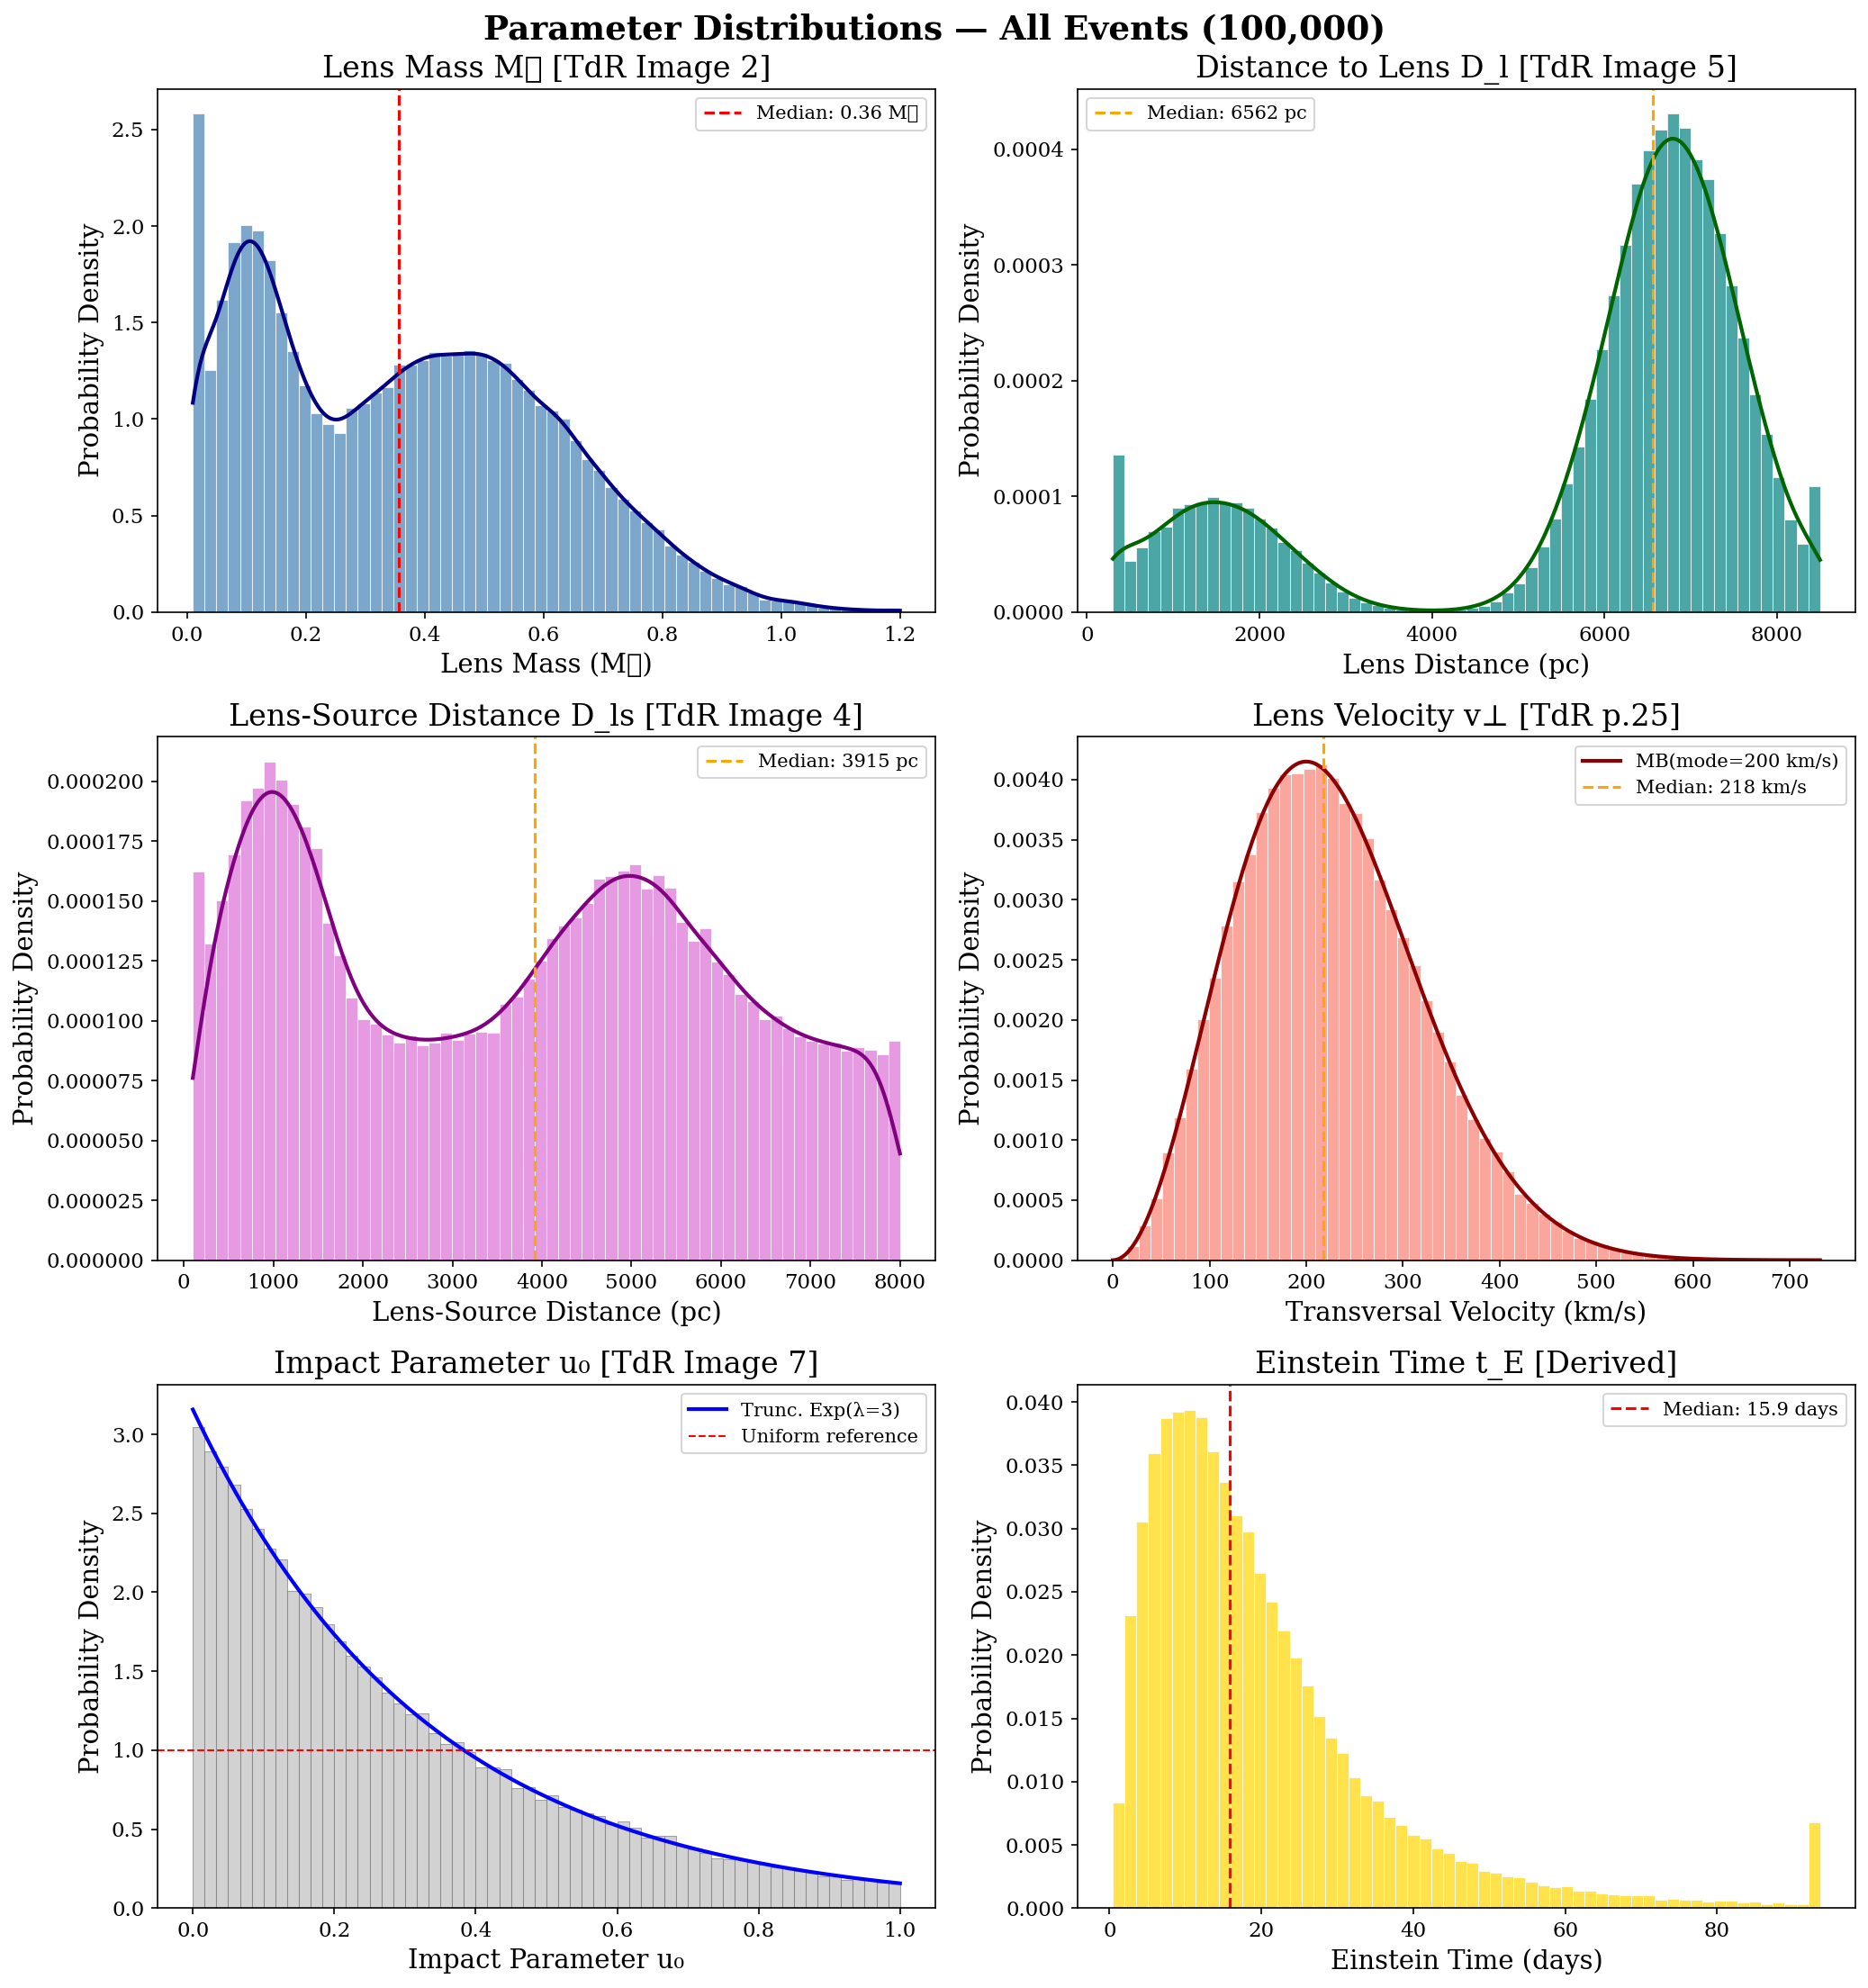

Saved: distributions_common.png


In [ ]:
# Cell 17: Parameter Distribution Histograms — Common Parameters
plot_dir = r'/content/drive/MyDrive/001-datasets/validation_plots'
os.makedirs(plot_dir, exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Parameter Distributions — All Events (100,000)', fontsize=18, fontweight='bold')

# 1. Lens Mass
ax = axes[0, 0]
ax.hist(M_star_solar, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='white', linewidth=0.5)
from scipy.stats import gaussian_kde
kde_mass = gaussian_kde(M_star_solar)
x_mass = np.linspace(0.01, 1.2, 300)
ax.plot(x_mass, kde_mass(x_mass), 'navy', lw=2)
ax.axvline(np.median(M_star_solar), color='red', ls='--', lw=1.5, label=f'Median: {np.median(M_star_solar):.2f} M☉')
ax.set_xlabel('Lens Mass (M☉)')
ax.set_ylabel('Probability Density')
ax.set_title('Lens Mass M★ [TdR Image 2]')
ax.legend()

# 2. Distance to Lens
ax = axes[0, 1]
ax.hist(D_l_pc, bins=60, density=True, alpha=0.7, color='teal', edgecolor='white', linewidth=0.5)
kde_dl = gaussian_kde(D_l_pc)
x_dl = np.linspace(300, 8500, 300)
ax.plot(x_dl, kde_dl(x_dl), 'darkgreen', lw=2)
ax.axvline(np.median(D_l_pc), color='orange', ls='--', lw=1.5, label=f'Median: {np.median(D_l_pc):.0f} pc')
ax.set_xlabel('Lens Distance (pc)')
ax.set_ylabel('Probability Density')
ax.set_title('Distance to Lens D_l [TdR Image 5]')
ax.legend()

# 3. Lens-Source Distance
ax = axes[1, 0]
ax.hist(D_ls_pc, bins=60, density=True, alpha=0.7, color='orchid', edgecolor='white', linewidth=0.5)
kde_dls = gaussian_kde(D_ls_pc)
x_dls = np.linspace(100, 8000, 300)
ax.plot(x_dls, kde_dls(x_dls), 'purple', lw=2)
ax.axvline(np.median(D_ls_pc), color='orange', ls='--', lw=1.5, label=f'Median: {np.median(D_ls_pc):.0f} pc')
ax.set_xlabel('Lens-Source Distance (pc)')
ax.set_ylabel('Probability Density')
ax.set_title('Lens-Source Distance D_ls [TdR Image 4]')
ax.legend()

# 4. Lens Velocity
ax = axes[1, 1]
ax.hist(v_perp_kms, bins=60, density=True, alpha=0.7, color='salmon', edgecolor='white', linewidth=0.5)
x_vel = np.linspace(0, v_perp_kms.max(), 300)
mb_pdf = stats.maxwell.pdf(x_vel, scale=200.0/np.sqrt(2.0))
ax.plot(x_vel, mb_pdf, 'darkred', lw=2, label='MB(mode=200 km/s)')
ax.axvline(np.median(v_perp_kms), color='orange', ls='--', lw=1.5, label=f'Median: {np.median(v_perp_kms):.0f} km/s')
ax.set_xlabel('Transversal Velocity (km/s)')
ax.set_ylabel('Probability Density')
ax.set_title('Lens Velocity v⊥ [TdR p.25]')
ax.legend()

# 5. Impact Parameter
ax = axes[2, 0]
ax.hist(u0_all, bins=60, density=True, alpha=0.7, color='silver', edgecolor='gray', linewidth=0.5)
x_u0 = np.linspace(0, 1, 300)
trunc_exp_pdf = 3.0 * np.exp(-3.0 * x_u0) / (1.0 - np.exp(-3.0))
ax.plot(x_u0, trunc_exp_pdf, 'blue', lw=2, label='Trunc. Exp(λ=3)')
ax.axhline(1.0, color='red', ls='--', lw=1, label='Uniform reference')
ax.set_xlabel('Impact Parameter u₀')
ax.set_ylabel('Probability Density')
ax.set_title('Impact Parameter u₀ [TdR Image 7]')
ax.legend()

# 6. Einstein Time
ax = axes[2, 1]
t_E_plot = np.clip(t_E_days, 0, np.percentile(t_E_days, 99))
ax.hist(t_E_plot, bins=60, density=True, alpha=0.7, color='gold', edgecolor='white', linewidth=0.5)
ax.axvline(np.median(t_E_days), color='red', ls='--', lw=1.5, label=f'Median: {np.median(t_E_days):.1f} days')
ax.set_xlabel('Einstein Time (days)')
ax.set_ylabel('Probability Density')
ax.set_title('Einstein Time t_E [Derived]')
ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(plot_dir, 'distributions_common.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: distributions_common.png")

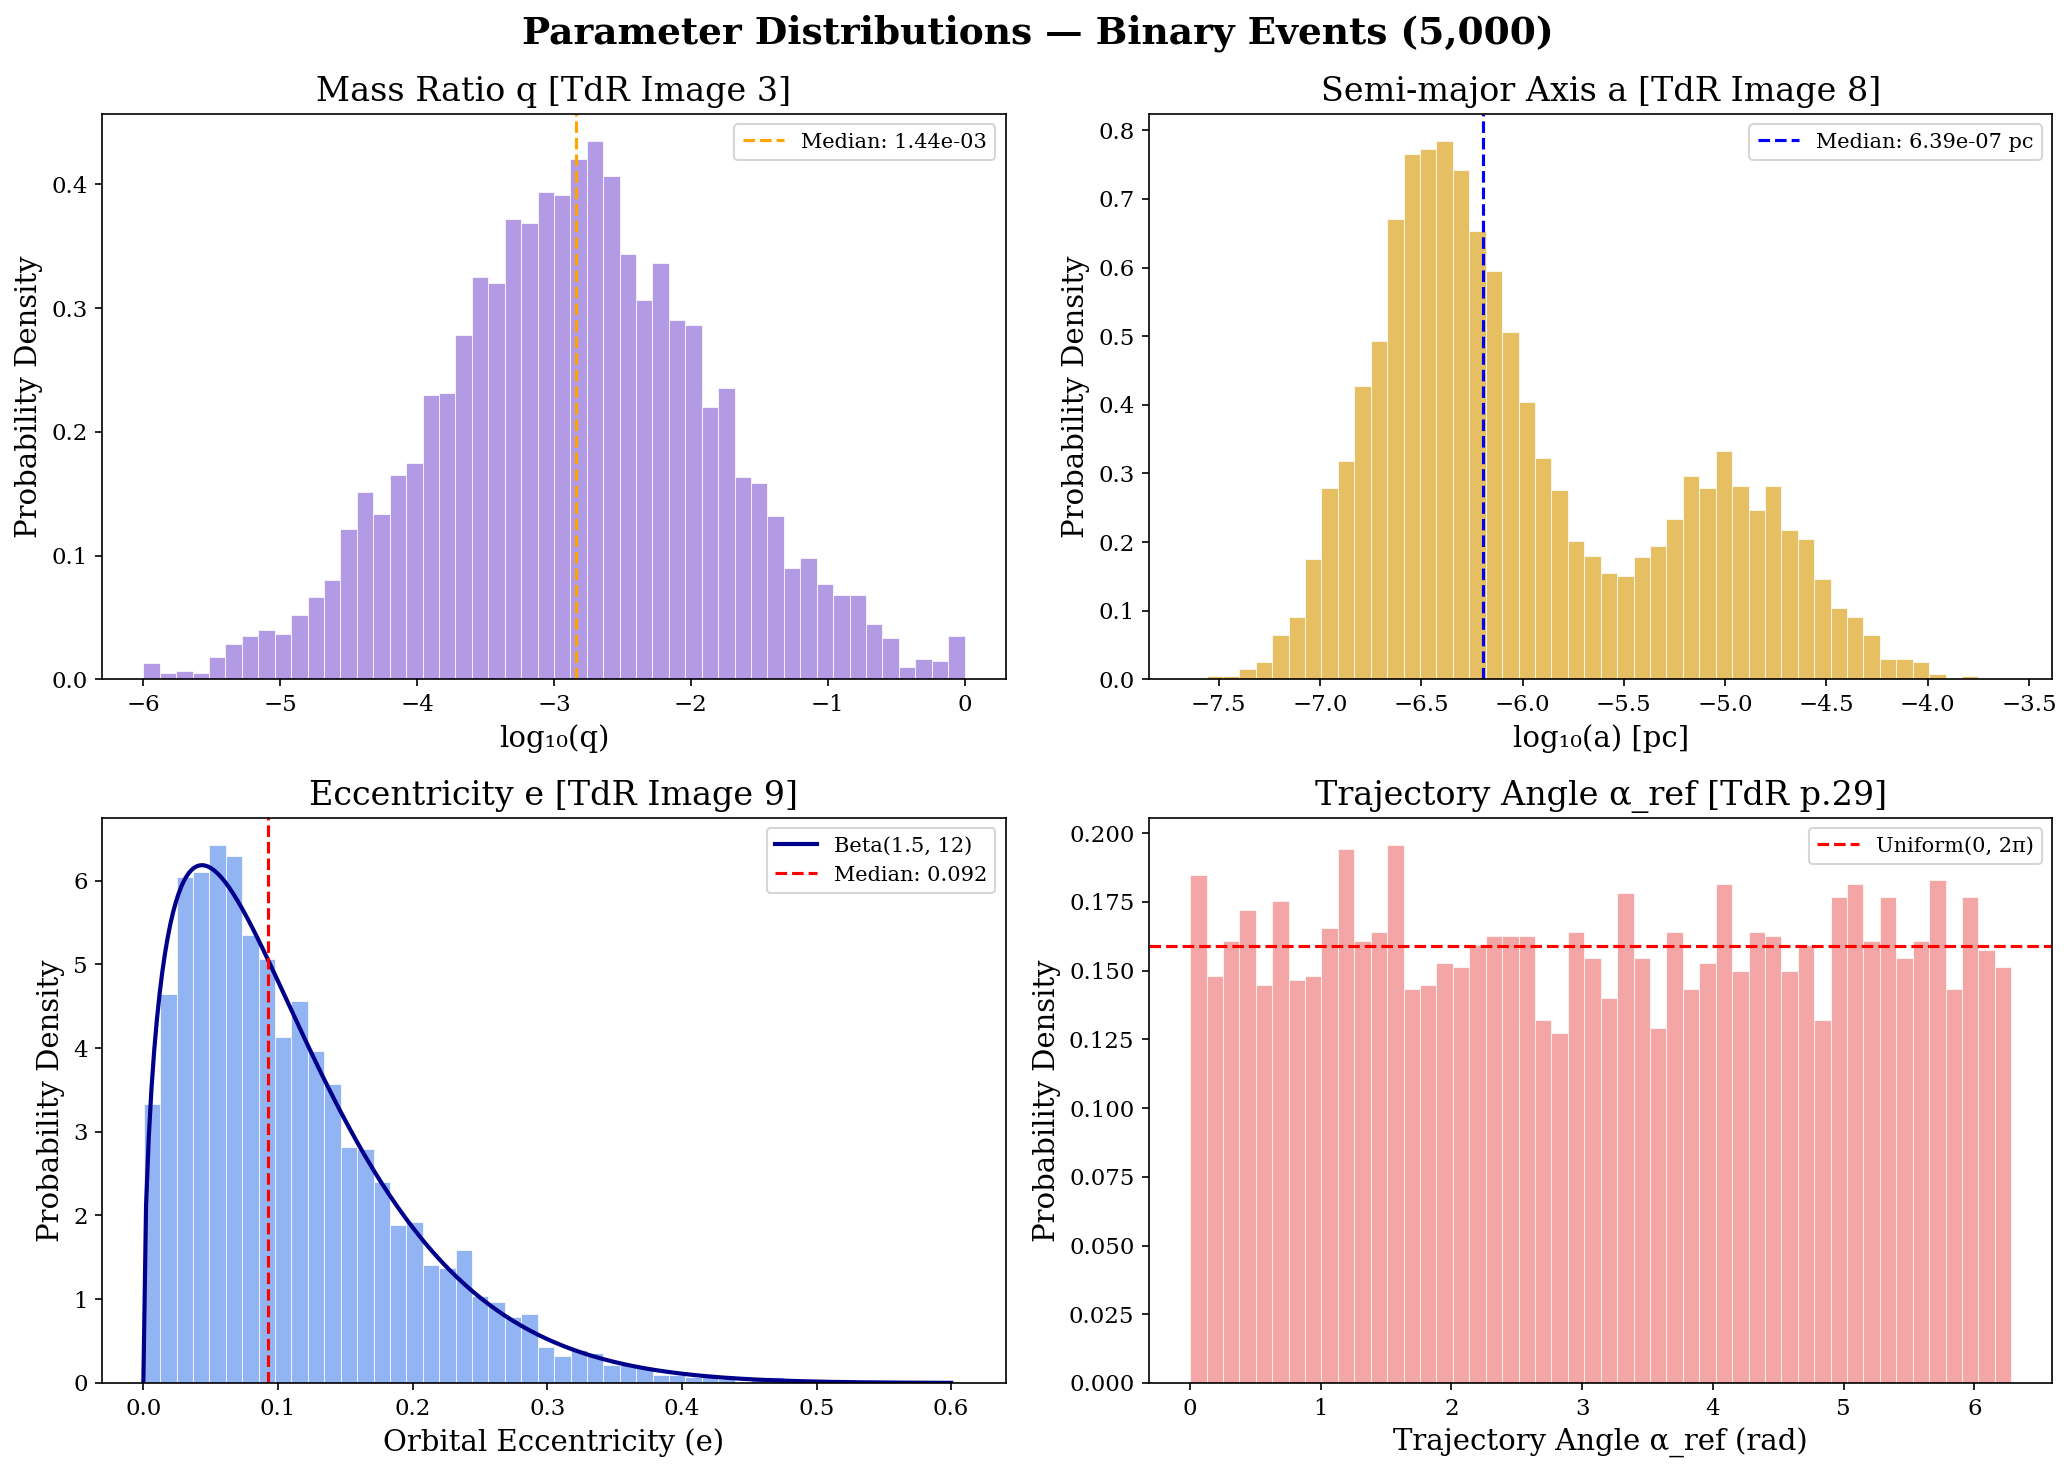

Saved: distributions_binary.png


In [ ]:
# Cell 18: Parameter Distribution Histograms — Binary-Only Parameters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parameter Distributions — Binary Events (5,000)', fontsize=18, fontweight='bold')

# 1. Mass Ratio (log scale)
ax = axes[0, 0]
ax.hist(np.log10(q_binary), bins=50, density=True, alpha=0.7, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.axvline(np.log10(np.median(q_binary)), color='orange', ls='--', lw=1.5, label=f'Median: {np.median(q_binary):.2e}')
ax.set_xlabel('log₁₀(q)')
ax.set_ylabel('Probability Density')
ax.set_title('Mass Ratio q [TdR Image 3]')
ax.legend()

# 2. Semi-major Axis (log scale)
ax = axes[0, 1]
ax.hist(np.log10(a_pc_binary), bins=50, density=True, alpha=0.7, color='goldenrod', edgecolor='white', linewidth=0.5)
ax.axvline(np.log10(np.median(a_pc_binary)), color='blue', ls='--', lw=1.5, label=f'Median: {np.median(a_pc_binary):.2e} pc')
ax.set_xlabel('log₁₀(a) [pc]')
ax.set_ylabel('Probability Density')
ax.set_title('Semi-major Axis a [TdR Image 8]')
ax.legend()

# 3. Eccentricity
ax = axes[1, 0]
ax.hist(e_binary, bins=50, density=True, alpha=0.7, color='cornflowerblue', edgecolor='white', linewidth=0.5)
x_ecc = np.linspace(0, 0.6, 300)
beta_pdf = stats.beta.pdf(x_ecc, 1.5, 12.0)
ax.plot(x_ecc, beta_pdf, 'darkblue', lw=2, label='Beta(1.5, 12)')
ax.axvline(np.median(e_binary), color='red', ls='--', lw=1.5, label=f'Median: {np.median(e_binary):.3f}')
ax.set_xlabel('Orbital Eccentricity (e)')
ax.set_ylabel('Probability Density')
ax.set_title('Eccentricity e [TdR Image 9]')
ax.legend()

# 4. Trajectory Angle
ax = axes[1, 1]
ax.hist(alpha_ref_binary, bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='white', linewidth=0.5)
ax.axhline(1.0/(2*np.pi), color='red', ls='--', lw=1.5, label='Uniform(0, 2π)')
ax.set_xlabel('Trajectory Angle α_ref (rad)')
ax.set_ylabel('Probability Density')
ax.set_title('Trajectory Angle α_ref [TdR p.29]')
ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(plot_dir, 'distributions_binary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: distributions_binary.png")

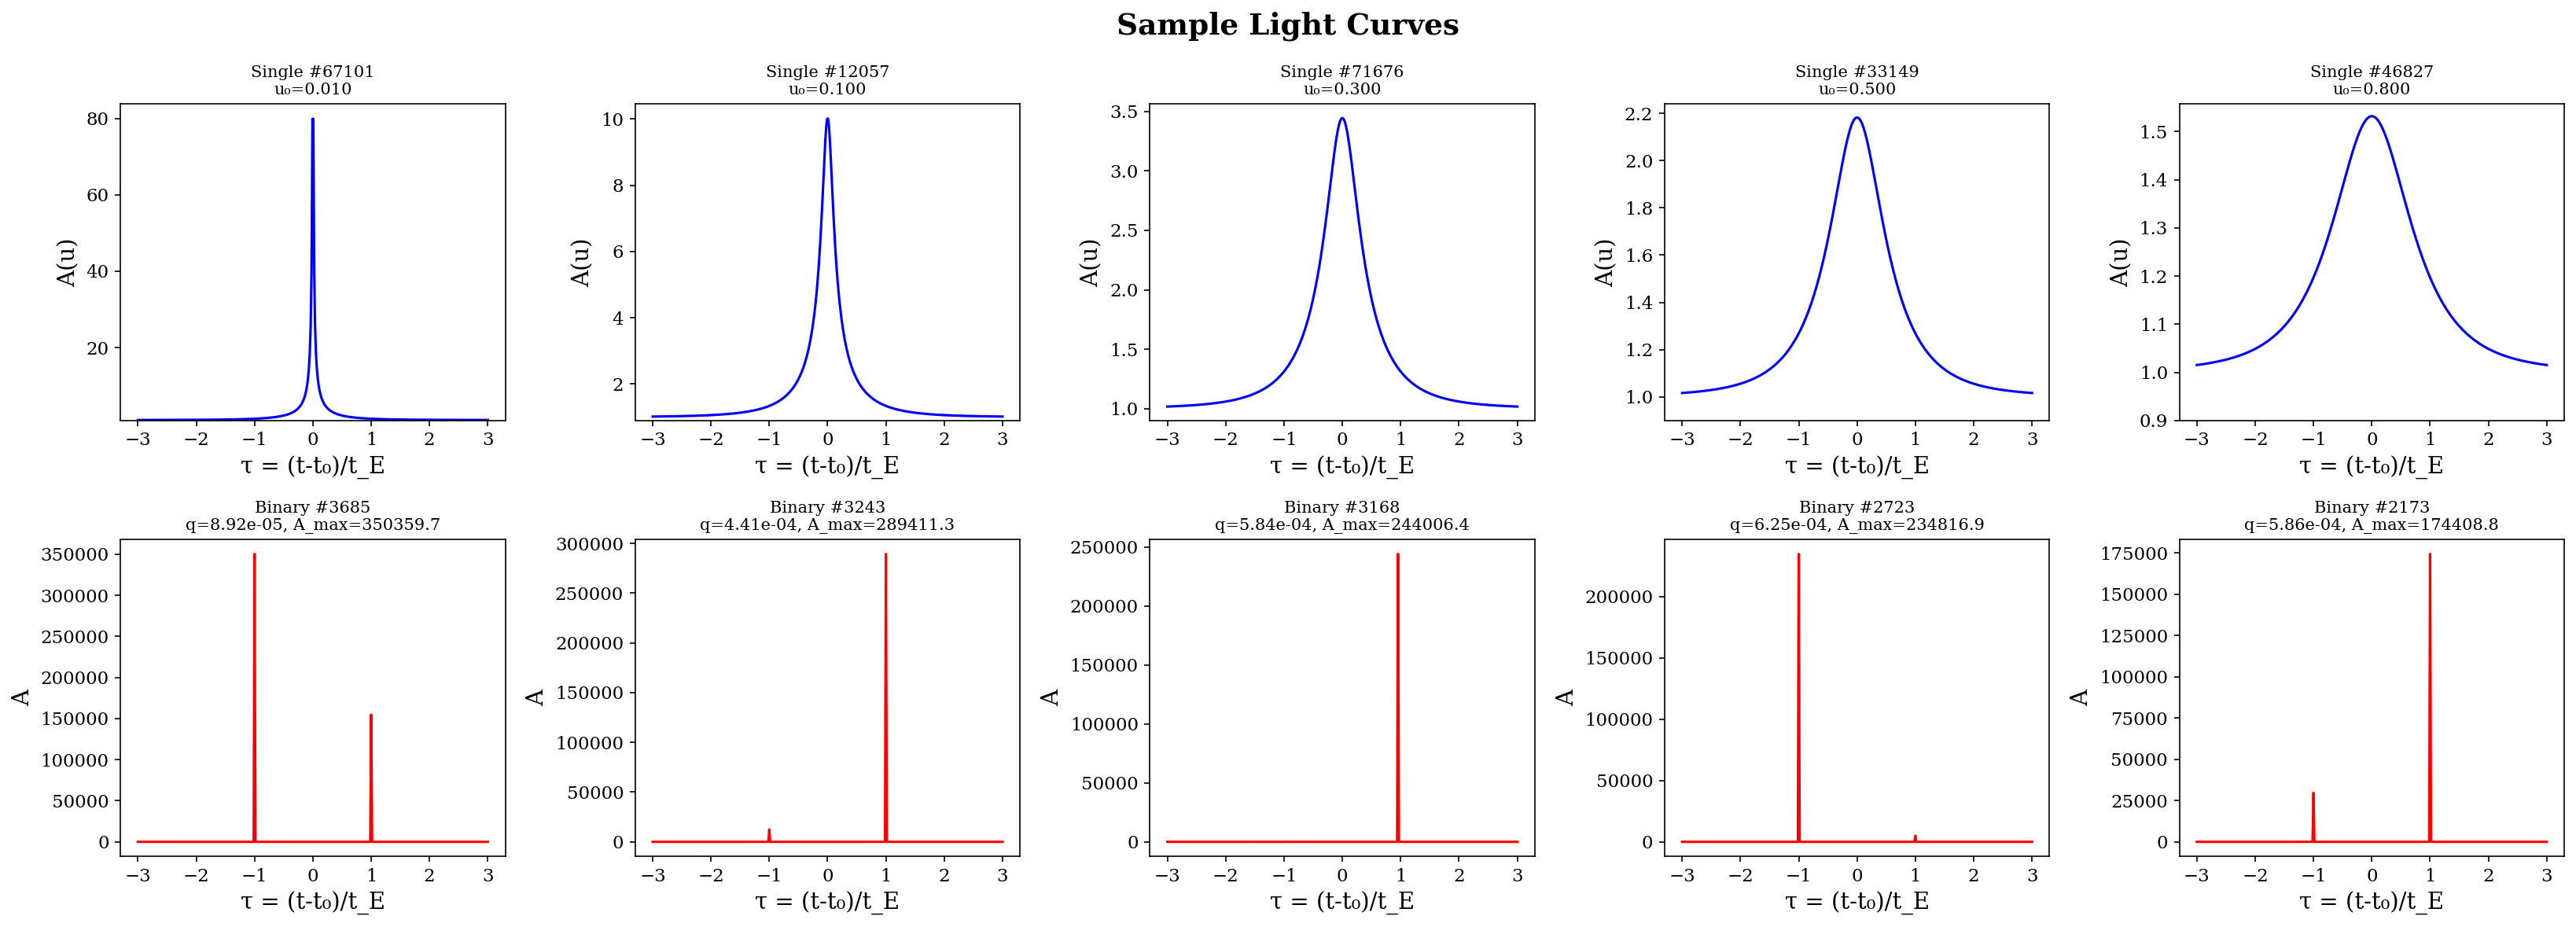

Saved: sample_lightcurves.png


In [ ]:
# Cell 19: Sample Light Curves
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('Sample Light Curves', fontsize=18, fontweight='bold')
tau_plot = np.linspace(-3, 3, N_TIME)

# Select 5 single lens events with varying u₀
single_indices = np.array([
    np.argmin(np.abs(u0_all[:N_SINGLE] - target))
    for target in [0.01, 0.1, 0.3, 0.5, 0.8]
])

for j, idx in enumerate(single_indices):
    ax = axes[0, j]
    ax.plot(tau_plot, single_lightcurves[idx, :], 'b-', lw=1.5)
    ax.set_title(f'Single #{idx}\nu₀={u0_all[idx]:.3f}', fontsize=10)
    ax.set_xlabel('τ = (t-t₀)/t_E')
    ax.set_ylabel('A(u)')
    ax.set_ylim(bottom=0.9)

# Select 5 binary lens events with highest peak amplification (most interesting)
binary_peaks = binary_lightcurves.max(axis=1)
binary_interesting = np.argsort(binary_peaks)[-5:][::-1]

for j, idx in enumerate(binary_interesting):
    ax = axes[1, j]
    ax.plot(tau_plot, binary_lightcurves[idx, :], 'r-', lw=1.5)
    ax.set_title(f'Binary #{idx}\nq={q_binary[idx]:.2e}, A_max={binary_peaks[idx]:.1f}', fontsize=10)
    ax.set_xlabel('τ = (t-t₀)/t_E')
    ax.set_ylabel('A')

plt.tight_layout()
fig.savefig(os.path.join(plot_dir, 'sample_lightcurves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_lightcurves.png")

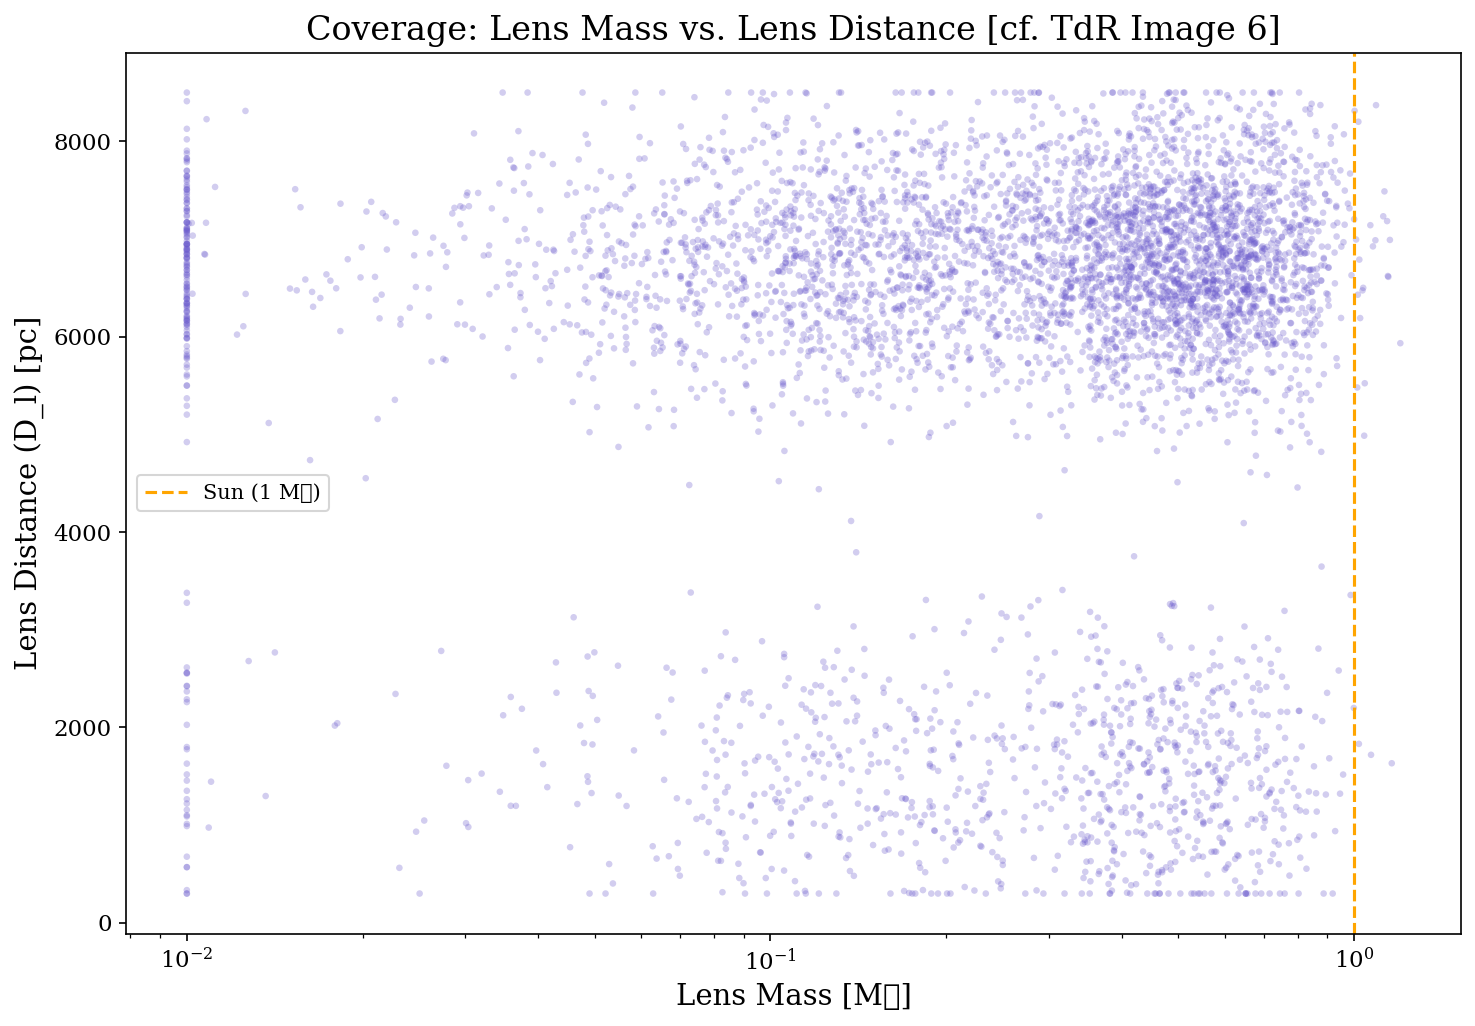

Saved: coverage_mass_distance.png


In [ ]:
# Cell 20: Coverage Plot — Lens Mass vs Distance (compare with TdR Image 6)
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    M_star_solar[:5000], D_l_pc[:5000],
    c='slateblue', alpha=0.3, s=10, edgecolors='none'
)
ax.axvline(1.0, color='orange', ls='--', lw=1.5, label='Sun (1 M☉)')
ax.set_xlabel('Lens Mass [M☉]')
ax.set_ylabel('Lens Distance (D_l) [pc]')
ax.set_title('Coverage: Lens Mass vs. Lens Distance [cf. TdR Image 6]')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(plot_dir, 'coverage_mass_distance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: coverage_mass_distance.png")

## Done!
The dataset has been generated and saved. All validation plots are in the `validation_plots/` directory.
